In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
url = "https://raw.githubusercontent.com/NepalStockData/Nepal_Stock_Data/main/Nepse_Data/Manufacturing_And_Processing/SHIVM.csv"
df = pd.read_csv(url)

In [8]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,1,2026-09-16,682.00,687.90,675.00,676.30,-0.69,"243,901.00","165,709,479.50"
1,2,2026-09-15,685.00,690.00,673.00,681.00,1.64,"462,655.00","315,697,044.30"
2,3,2026-09-14,663.00,675.00,663.00,670.00,1.06,"158,053.00","105,980,691.10"
3,4,2026-09-11,659.00,667.00,654.00,663.00,1.44,"104,620.00","69,234,644.80"
4,5,2026-09-10,663.00,665.00,652.10,653.60,-1.36,"99,214.00","65,476,402.30"


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1706 entries, 0 to 1705
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.N.      1706 non-null   int64  
 1   Date      1706 non-null   object 
 2   Open      1706 non-null   object 
 3   High      1706 non-null   object 
 4   Low       1706 non-null   object 
 5   Ltp       1706 non-null   object 
 6   % Change  1706 non-null   float64
 7   Qty       1706 non-null   object 
 8   Turnover  1706 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 120.1+ KB


In [11]:
df[df.isnull().any(axis=1)]

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1706 entries, 0 to 1705
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   S.N.      1706 non-null   int64         
 1   Date      1706 non-null   datetime64[ns]
 2   Open      1706 non-null   object        
 3   High      1706 non-null   object        
 4   Low       1706 non-null   object        
 5   Ltp       1706 non-null   object        
 6   % Change  1706 non-null   float64       
 7   Qty       1706 non-null   object        
 8   Turnover  1706 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 120.1+ KB


In [14]:
df.iloc[:,1:]

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,2026-09-16,682.00,687.90,675.00,676.30,-0.69,"243,901.00","165,709,479.50"
1,2026-09-15,685.00,690.00,673.00,681.00,1.64,"462,655.00","315,697,044.30"
2,2026-09-14,663.00,675.00,663.00,670.00,1.06,"158,053.00","105,980,691.10"
3,2026-09-11,659.00,667.00,654.00,663.00,1.44,"104,620.00","69,234,644.80"
4,2026-09-10,663.00,665.00,652.10,653.60,-1.36,"99,214.00","65,476,402.30"
...,...,...,...,...,...,...,...,...
1701,2019-03-28,323.00,353.00,323.00,333.00,-2.06,"78,450.00","26,284,816.00"
1702,2019-03-27,323.00,350.00,306.00,340.00,0.00,"170,472.00","55,440,896.00"
1703,2019-03-26,359.00,359.00,340.00,340.00,-9.81,500.00,"173,150.00"
1704,2019-03-25,398.00,398.00,377.00,377.00,-9.81,90.00,"34,350.00"


In [22]:
cols = ['Open','High','Low','Ltp','Qty','Turnover']

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1706 entries, 0 to 1705
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   S.N.      1706 non-null   int64         
 1   Date      1706 non-null   datetime64[ns]
 2   Open      1706 non-null   float64       
 3   High      1706 non-null   float64       
 4   Low       1706 non-null   float64       
 5   Ltp       1706 non-null   float64       
 6   % Change  1706 non-null   float64       
 7   Qty       1706 non-null   float64       
 8   Turnover  1706 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 120.1 KB


In [31]:
df.nlargest(10, 'Ltp')[['Date','Ltp','Turnover']]


,Date,Ltp,Turnover
1175,2021-08-19,1800.0,325000194.8
1176,2021-08-18,1793.0,420538937.3
1174,2021-08-24,1750.0,192745104.4
1171,2021-08-29,1700.0,183673239.4
1173,2021-08-25,1699.0,209456738.8
1172,2021-08-26,1681.0,112350845.9
1321,2021-01-18,1670.0,86110281.0
1323,2021-01-13,1660.0,163613761.0
1322,2021-01-17,1655.0,96985081.0
1317,2021-01-24,1648.0,104388840.0


In [34]:
df.loc[df['Ltp'].idxmax()]

S.N.                       1176
Date        2021-08-19 00:00:00
Open                     1828.8
High                     1910.0
Low                      1793.0
Ltp                      1800.0
% Change                   0.39
Qty                    176321.0
Turnover            325000194.8
Name: 1175, dtype: object

In [35]:
df.loc[df['Ltp'].idxmin()]

S.N.                       1686
Date        2019-04-22 00:00:00
Open                      305.0
High                      311.0
Low                       304.0
Ltp                       305.0
% Change                    0.0
Qty                     20035.0
Turnover              6140385.0
Name: 1685, dtype: object

In [37]:
df.nsmallest(10, 'Ltp') [[
    'Date','Turnover','Ltp','% Change']]

,Date,Turnover,Ltp,% Change
1685,2019-04-22,6140385.0,305.0,0.00
1686,2019-04-21,5510580.0,305.0,-1.29
1688,2019-04-17,5994927.0,305.0,-1.93
1691,2019-04-11,4957450.0,306.0,-0.65
1683,2019-04-24,7033530.0,307.0,-0.97
1690,2019-04-15,1329135.0,308.0,0.65
1692,2019-04-10,4560692.0,308.0,-0.65
1687,2019-04-18,5411860.0,309.0,1.31
1682,2019-04-25,6451663.0,310.0,0.98
1684,2019-04-23,7136660.0,310.0,1.64


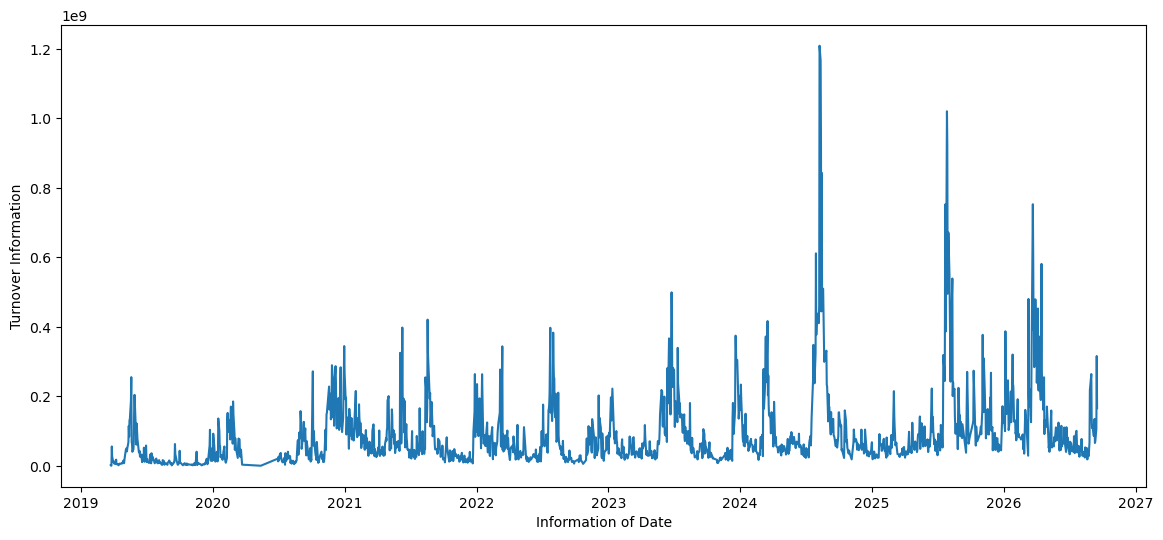

In [106]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'],df['Turnover'])
plt.xlabel("Information of Date")
plt.ylabel("Turnover Information")
plt.show()

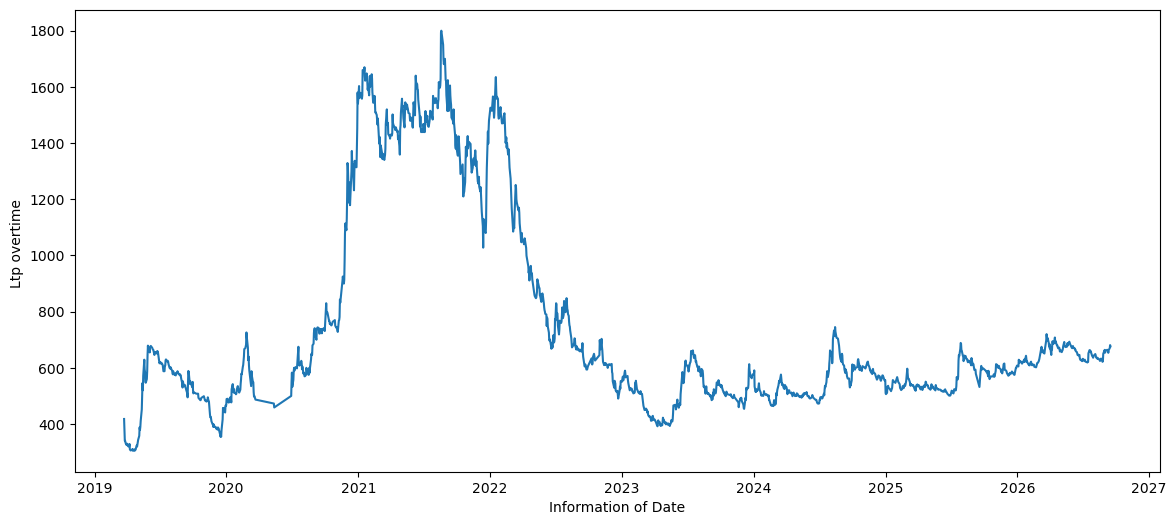

In [52]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'],df['Ltp'])
plt.xlabel("Information of Date")
plt.ylabel("Ltp overtime ")
plt.show()

In [47]:
d_22_26 = (
    (df['Date'] >= '2022-01-01') &
    (df['Date'] <= '2026-12-31')
)

In [49]:
d_22_26 = df[d_22_26]

In [50]:
d_22_26.nlargest(10, 'Ltp') [['Date','Ltp','Turnover']]

,Date,Ltp,Turnover
1081,2022-01-17,1635.0,211235916.2
1082,2022-01-16,1607.0,263378622.7
1080,2022-01-18,1590.0,143744898.5
1087,2022-01-09,1566.0,193989035.5
1078,2022-01-20,1565.0,63536012.1
1079,2022-01-19,1558.0,96432914.3
1077,2022-01-23,1557.1,70327655.3
1086,2022-01-10,1545.0,124449335.5
1072,2022-01-30,1528.0,124497760.7
1092,2022-01-02,1526.0,234981678.8


[]

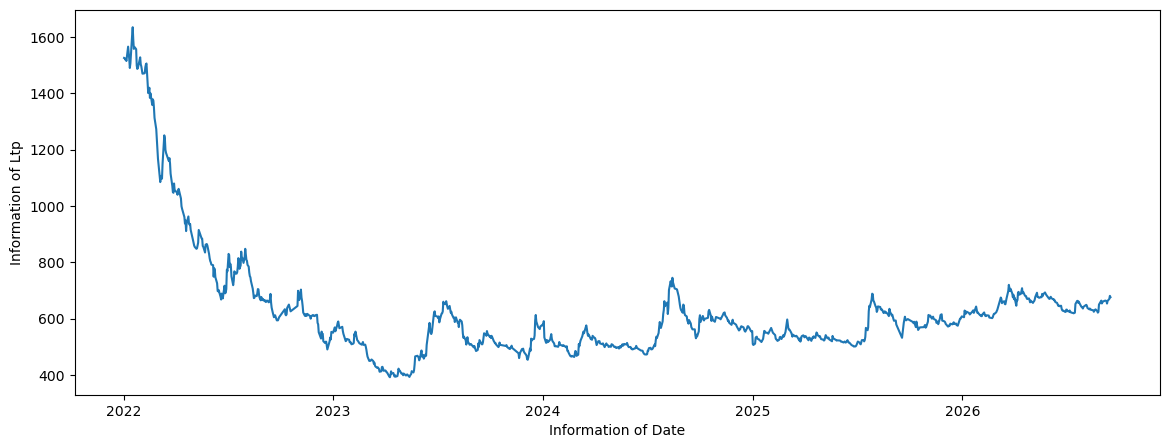

In [55]:
plt.figure(figsize=(14,5))
plt.plot(d_22_26['Date'],d_22_26['Ltp'])
plt.xlabel("Information of Date")
plt.ylabel("Information of Ltp")
plt.plot()           #vey dangerous fall, got less than 40 percent bonus share combined and fall is more than 75% from abpve high..

In [57]:
d_22_26.iloc[d_22_26['Ltp'].idxmax()]

S.N.                       1082
Date        2022-01-17 00:00:00
Open                     1639.1
High                     1671.8
Low                      1580.0
Ltp                      1635.0
% Change                   1.74
Qty                    128877.0
Turnover            211235916.2
Name: 1081, dtype: object

In [59]:
d_22_26.iloc[d_22_26['Ltp'].idxmin()]

S.N.                        790
Date        2023-04-10 00:00:00
Open                      395.0
High                      402.8
Low                       389.8
Ltp                       392.0
% Change                  -0.51
Qty                    173577.0
Turnover             68418643.3
Name: 789, dtype: object

In [77]:
df_20_21 = (
    (df['Date'] >= '2020-01-01') &
    (df['Date'] <= '2021-12-31') 
)

In [83]:
d_20_21 = df[
    (df['Date'] >= '2020-01-01') &
    (df['Date'] <= '2022-12-31')
]

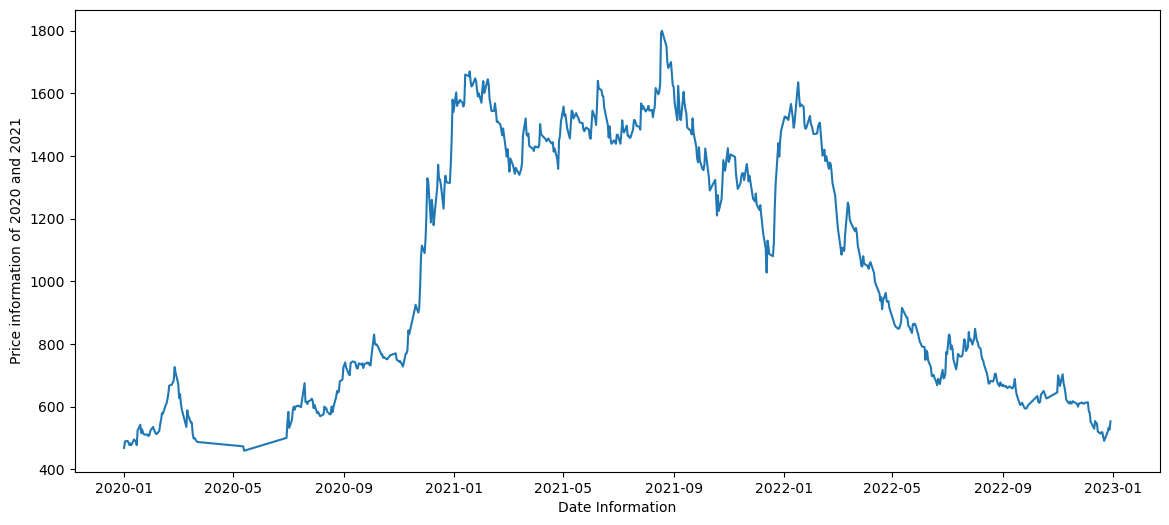

In [85]:
plt.figure(figsize=(14,6))
plt.plot(d_20_21['Date'],d_20_21['Ltp'])
plt.xlabel("Date Information")
plt.ylabel("Price information of 2020 and 2021")
plt.show()

In [88]:
df[df.isnull().any(axis=1)]

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover


[]

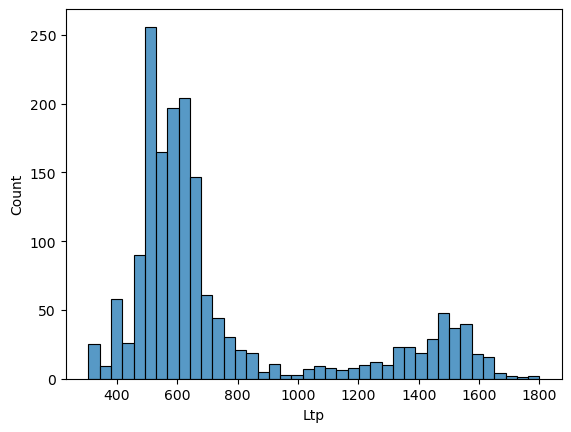

In [91]:
sns.histplot(df['Ltp'])
plt.plot()

[]

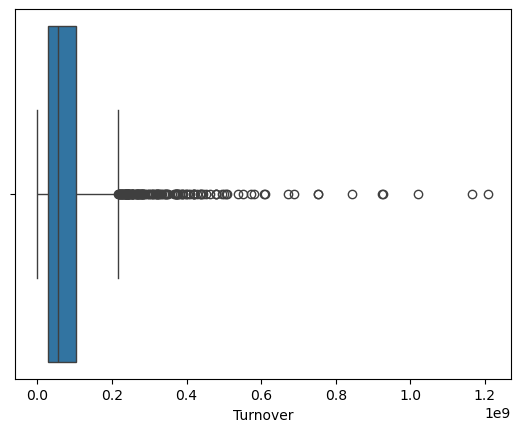

In [93]:
sns.boxplot(x=df['Turnover'])
plt.plot()

[]

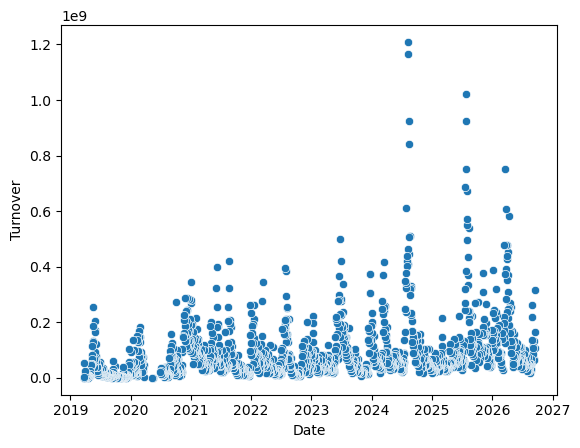

In [99]:
sns.scatterplot(x=df['Date'], y=df['Turnover'])
plt.plot()

[]

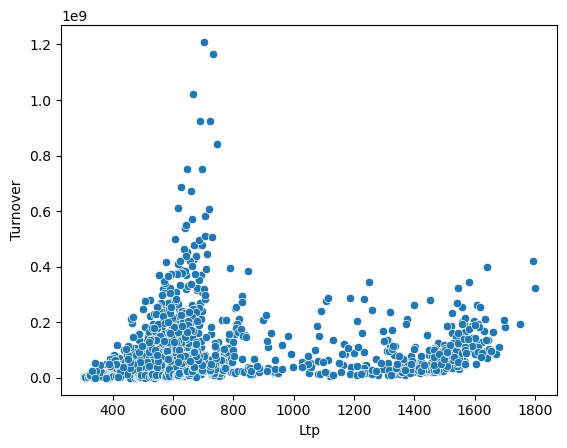

In [100]:
sns.scatterplot(x=df['Ltp'], y=df['Turnover'])
plt.plot()

[]

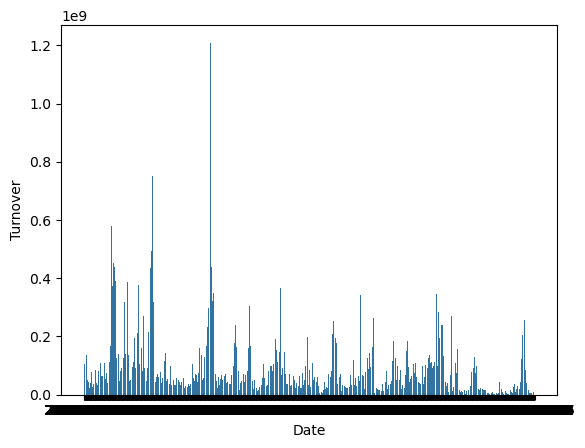

In [105]:
sns.barplot(data=df, x=df['Date'], y=df['Turnover'])
plt.plot()

In [108]:
seventy_fifth = df['Ltp'].quantile(0.75)
twenty_fifth = df['Ltp'].quantile(0.25)
iqr = seventy_fifth-twenty_fifth
print(iqr)

226.90249999999992


In [112]:
upper = seventy_fifth+(1.5*iqr)
lower = twenty_fifth+(1.5*iqr)
print(upper, lower)

1091.1037499999998 864.20125


In [114]:
df['Year'] = df['Date'].dt.year

In [124]:
df.groupby('Year').agg(
    Average_Ltp=("Ltp", "mean"),
    Max_Ltp=("Ltp","max"),
    Min_Ltp=("Ltp","min")
)

,Average_Ltp,Max_Ltp,Min_Ltp
Year,,,
2019,502.478947,679.00,305.00
2020,735.521739,1580.00,459.00
2021,1464.419665,1800.00,1027.90
2022,886.716116,1635.00,490.60
2023,507.206167,662.00,392.00
2024,549.012069,745.10,463.90
2025,561.268844,688.64,501.05
2026,649.700599,720.00,601.90


In [ ]:
df['Month'] = df['Month']dt.year